## 2.1 NetCDF format. Introduction

Geophysical data can be stored in many different formats: **binary**, **plain text**, **.csv**, **.xls**, **BUFR**, **HDF**, **GRIB**, and **NetCDF**.
Python libraries exist to handle all of these formats.

In recent years, **NetCDF** has become one of the preferred ways to store and distribute geophysical data.
In this course, we will work with data in **NetCDF format**.


### What is NetCDF?

**NetCDF** (Network Common Data Format) is:

> *“a set of machine‑independent data formats that support the creation, access, and sharing of array‑oriented scientific data.”*

It has become a **community standard** for sharing scientific data.


### Main characteristics of NetCDF data

- **Self‑Describing** — A NetCDF file includes information about the data it contains.
- **Portable** — A NetCDF file can be accessed by computers with different ways of storing integers, characters, and floating‑point numbers.
- **Scalable** — Small subsets of large datasets may be accessed efficiently through NetCDF interfaces, even from remote servers.
- **Appendable** — Data may be appended to a properly structured NetCDF file without copying the dataset or redefining its structure.

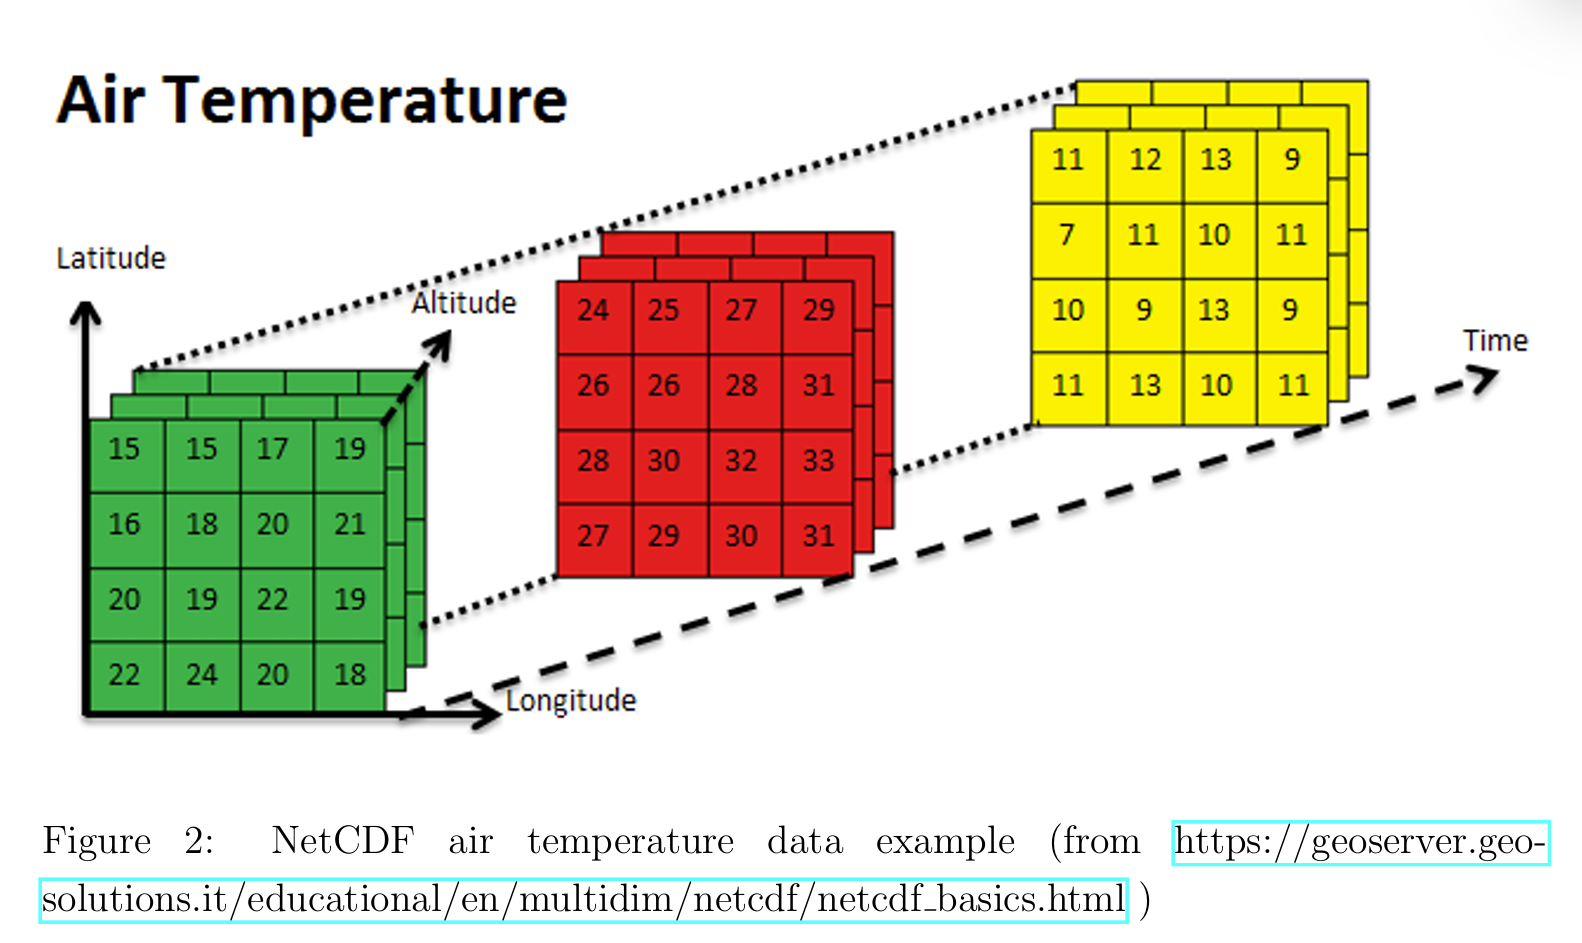
from https://geoserver.geo-solutions.it/educational/en/multidim/netcdf/netcdf_basics.html

## NetCDF file structure

NetCDF files have the extension **.nc** and their data structure is a multidimensional array composed of different variables and dimensions.

A NetCDF file contains:

- **Dimensions**
- **Variables**
- **Headers and attributes**

### Dimensions

Typical dimensions for geophysical data include:

- **longitude**
- **latitude**
- **vertical coordinate** (altitude or pressure levels)
- **time**

Other dimensions may also be used, such as **zonal wave number**.

### Variables

Each variable can have internal fields defining attributes such as:

- **missing value**
- **units**

### Headers and attributes

The file includes headers describing:

- internal variables
- dimensions
- global attributes



**Dimensions** for geophysical data are typically longitude, latitude, vertical coordinate (altitude or pressure levels) and time, however other dimensions are possible. For instance, to store the energy spectrum, one can use zonal wave number and time as the dimensions.

**Each variable** can have various internal fields defining specific attributes, for example missing value which defines the NoData for the variable or units attribute, specifying in which physical units the variable is measured. A NetCDF file also contains an header
section with the description of the internal variables, dimensions and global attributes.

There are multiple ways to access NetCDF data in Python using different libraries. In
the following subsections we will look at some of them.

## 2.2 netCDF4 library

The **netCDF4** library provides low-level access to NetCDF files. You read the data into numpy arrays and then work from there.

In the following series of examples, we will open a NetCDF file named *2000monthly-meant.nc*, which contains monthly mean temperatures for the year 2000 from the ERA‑40 database. We will examine its content and plot the surface temperature in Hamburg.


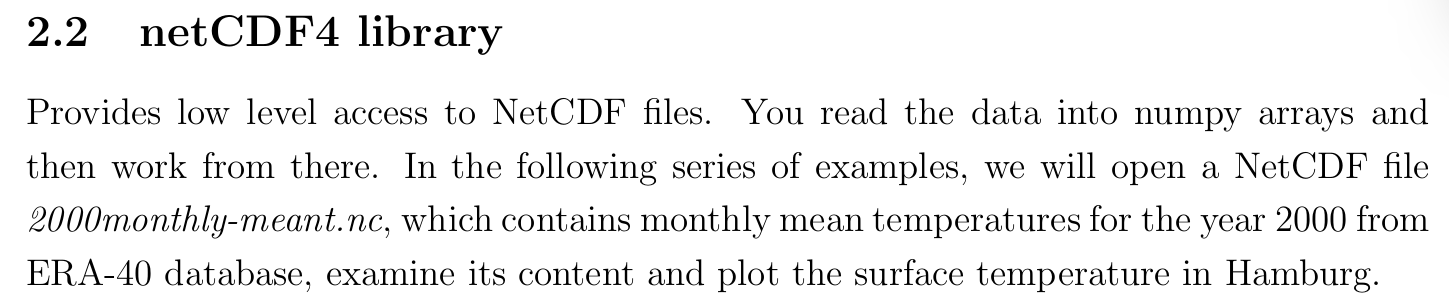

In [4]:
# netCDF4 example: opening dataset and printing its content
# import netCDF4 as nc
# fname = '2000monthly-meant.nc'
# ds = nc.Dataset(fname)
# print(ds)

RuntimeError: only endian='native' allowed for NETCDF3 files, got 'big' (variable 'longitude', group '/')

## 2.3 xarray package

The **xarray** package is an open‑source project designed to make working with labelled multi‑dimensional arrays simple, efficient, and enjoyable. It supports popular data formats such as NetCDF and GRIB, making it easier to locate, analyze, and visualize data.

xarray uses the **netCDF4** library as a low‑level interface. While it does not support all low‑level features of netCDF4 (such as modifying files on disk), it provides many additional features that simplify data analysis.

Documentation: http://xarray.pydata.org/en/stable/index.html

xarray will be our main tool for working with NetCDF data, and we will study it in detail in section 3.


# Working with xarray
## Opening dataset and examining its content
To get familiar with xarray we will use the same NetCDF file *2000monthly-meant.nc* that we already examined.

In [6]:
# xarray example: opening dataset and printing its content
import xarray as xr
fname = '2000monthly-meant.nc'
ds = xr.open_dataset(fname, engine="scipy")
print(ds)

<xarray.Dataset> Size: 9MB
Dimensions:    (longitude: 144, latitude: 73, level: 9, time: 12)
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * level      (level) int32 36B 1 10 100 200 300 500 700 850 1000
  * time       (time) datetime64[ns] 96B 2000-01-01 2000-02-01 ... 2000-12-01
Data variables:
    t          (time, level, latitude, longitude) float64 9MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2021-05-02 21:24:59 GMT by grib_to_netcdf-2.21.0: grib_to_n...


As with netCDF4 package, the output provided conveys the same information on Dimen
sions, Coordinates, and data variables, however in a much more readable form.
Now, let’s find more information on t variable:

In [8]:
# xarray: Examining variable
ds.t

<xarray.DataArray 't' (time: 12, level: 9, latitude: 73, longitude: 144)> Size: 9MB
[1135296 values with dtype=float64]
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * level      (level) int32 36B 1 10 100 200 300 500 700 850 1000
  * time       (time) datetime64[ns] 96B 2000-01-01 2000-02-01 ... 2000-12-01
Attributes:
    units:          K
    long_name:      Temperature
    standard_name:  air_temperature

## 3.2 Indexing and selecting data

Suppose we want to select sea level mean temperature data for the month of May 2000. There are 3 main ways to do so.

### 1. Usual numpy array slice operations

We recall (or find out by examining the `t`, `time`, and `level` variables in the NetCDF file) that:

- time and level are the first two dimensions for the temperature data,
- May corresponds to time index 4 (Python indices start from 0),
- sea level data (pressure level 1000 mbar) correspond to the last level.

Then we proceed as if `ds.t` were a numpy array.


In [ ]:
# Selecting sea level mean temperature data for May 2000 using slicing
ts1 = ds.t[4,-1,:,:]

2. xarray selection by index This approach does not require the knowledge of the
order of dimensions in the file, however we still need to find out the time index for May and level index for sea level.

In [9]:
# Selecting sea level mean temperature data for May 2000 using selection
# by index.
ts2 = ds.t.isel(time=4, level=-1)

3. xarray selection by value This approach does not require us to find out the time
and level indices of the required data, only their time and pressure values.

In [10]:
# Selecting sea level mean temperature data for May 2000 using selection
# by value.
import datetime
date1 = datetime.datetime(year=2000,day=1,month=5)
ts3 = ds.t.sel(time=date1,level=1000.0,method="nearest")

One can mix various selection types at liberty, for instance as follows:

In [11]:
# Mixing selection by index and by value
tsea=ds.t.sel(level=1000.0, method="nearest")
ts4=tsea.isel(time=4)

Selecting range of data One can use slice function for that.


In [13]:
# Mixing selection by index and by value
tsea=ds.t.sel(level=1000.0, method="nearest")
tl=tsea.isel(latitude=slice(10,30),longitude=slice(0,20))

## 3.3 Plotting data
xarray comes with powerful plot method that can automatically create plots of different
types based on the underlying data.

In [1]:
import xarray as xr
print(xr.__version__)

2024.9.0


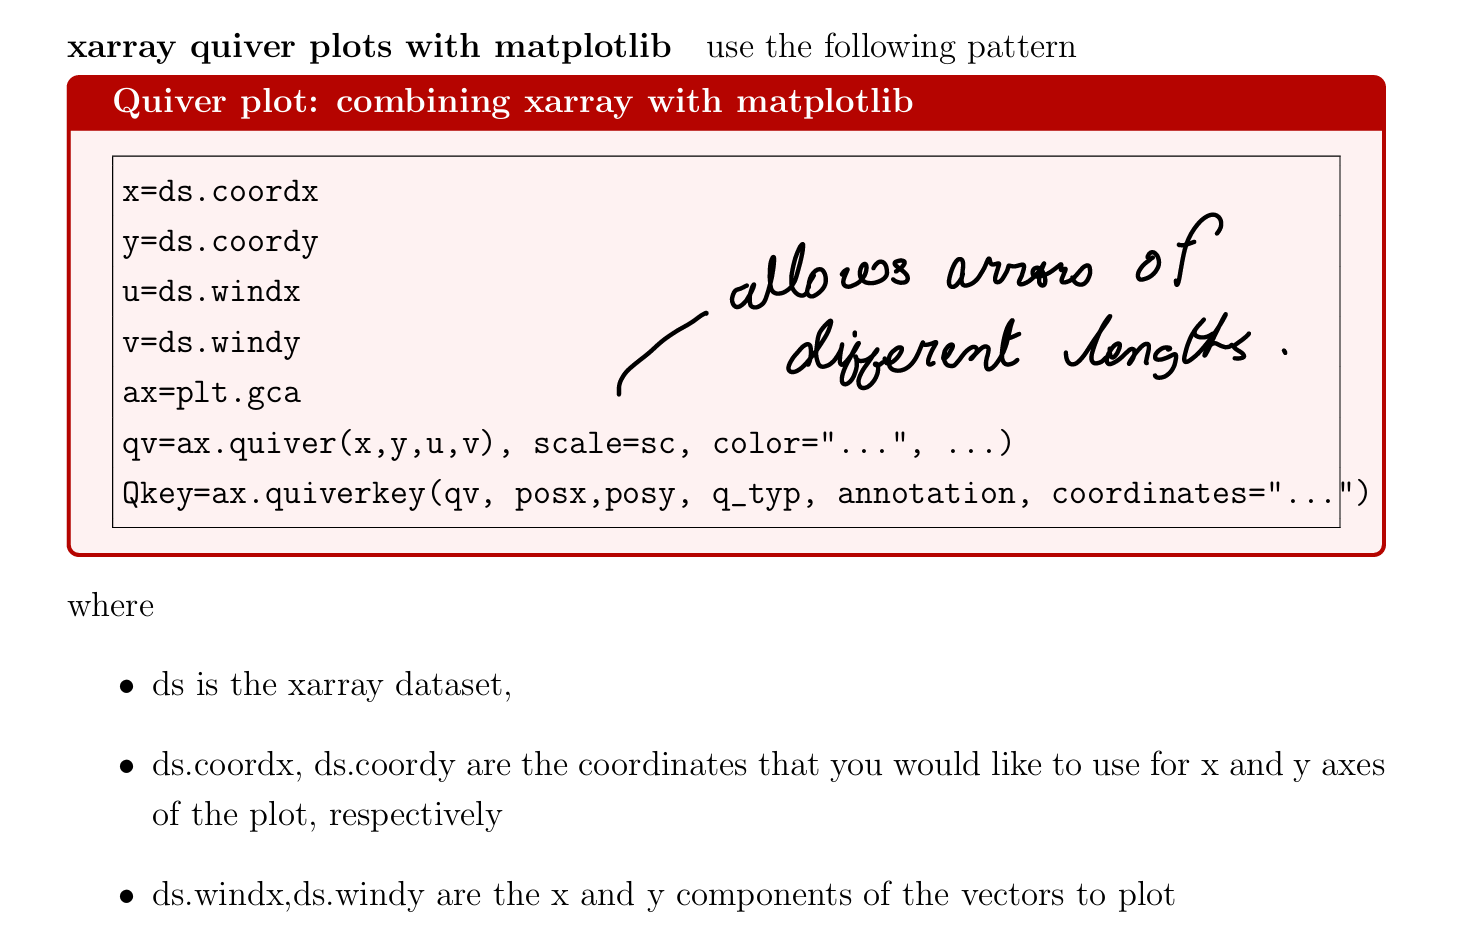

For quiverkey, it is good practice to select the median.


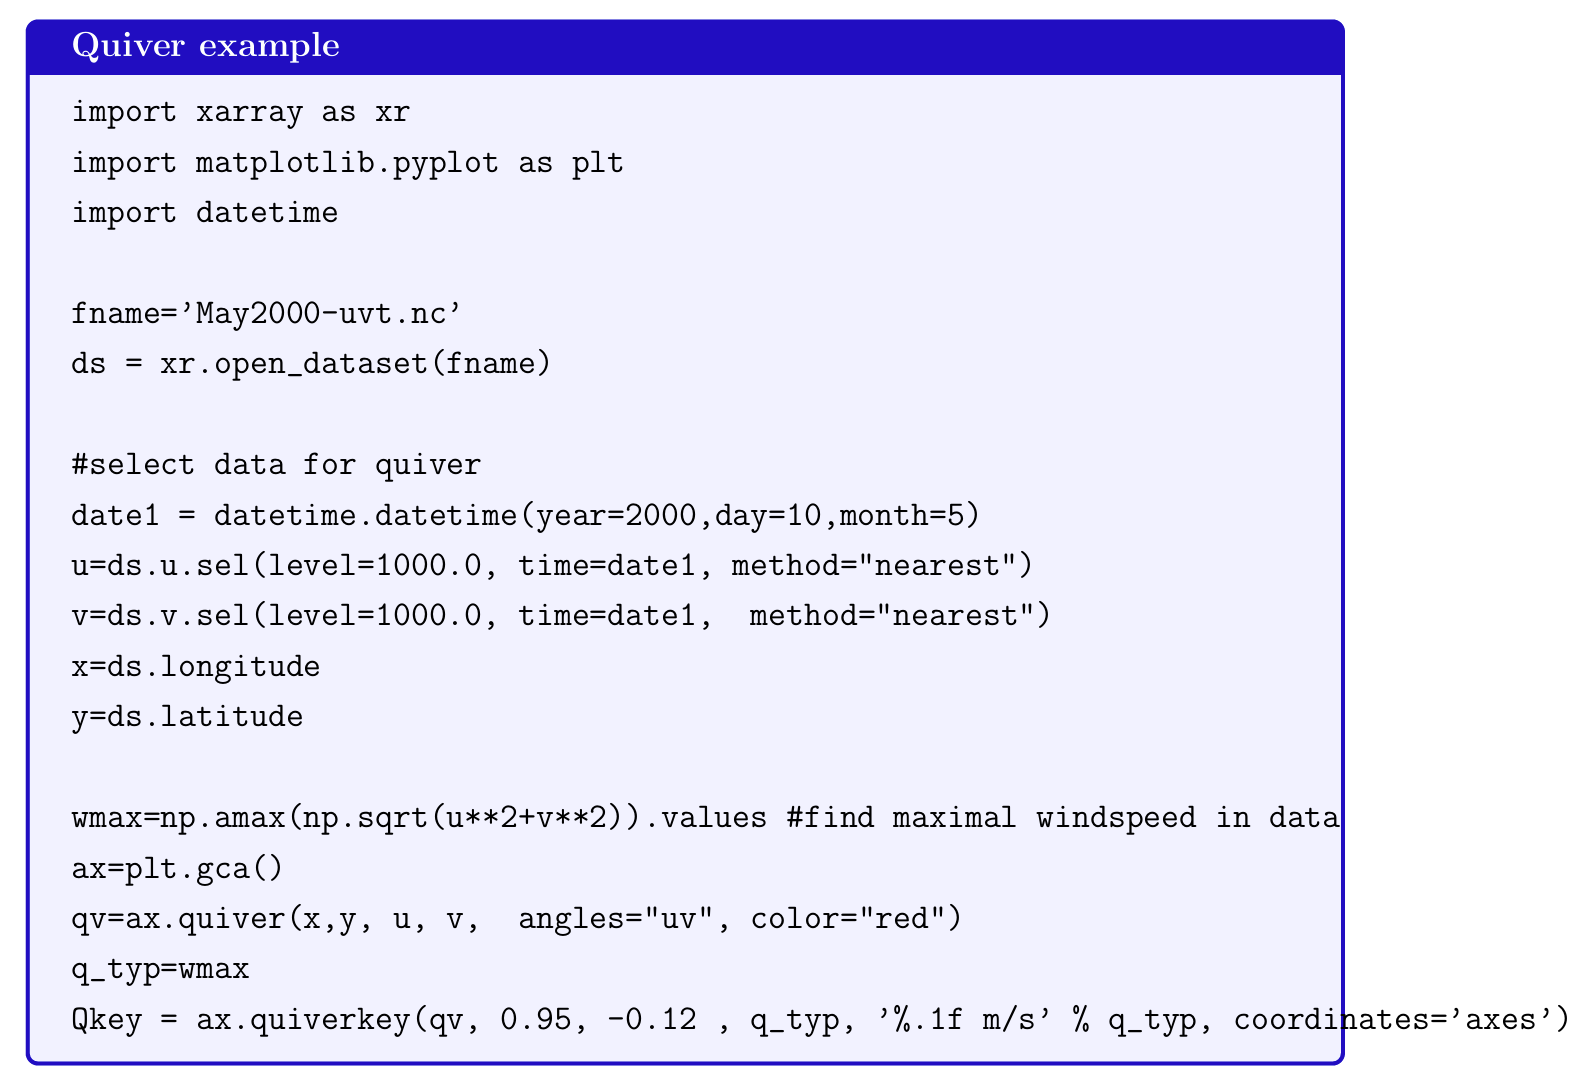
Angles tells how the arrows will be plotted. The angles are determined by the ratio of u and v and the angles does not matter if angles='uv' is selected.

If you draw a gradient field, use angles='xy'. This is because magnitude of u and v are not necessarily the same in xy coordinates.

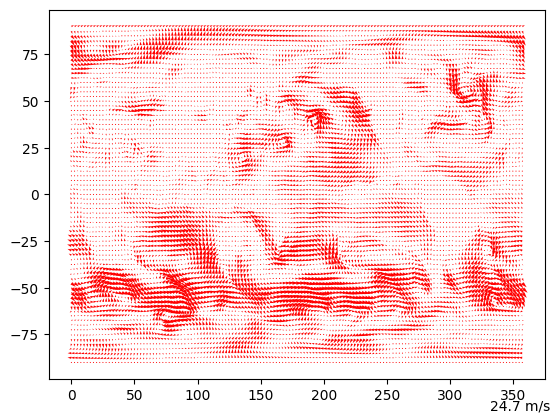

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import datetime
fname='May2000-uvt.nc'
ds = xr.open_dataset(fname, engine='scipy')
#select data for quiver
date1 = datetime.datetime(year=2000,day=10,month=5)
u=ds.u.sel(level=1000.0, time=date1, method="nearest")
v=ds.v.sel(level=1000.0, time=date1, method="nearest")
x=ds.longitude
y=ds.latitude
wmax=np.amax(np.sqrt(u**2+v**2)).values #find maximal windspeed in data
ax=plt.gca()
qv=ax.quiver(x,y, u, v, angles="uv", color="red")
q_typ=wmax
Qkey = ax.quiverkey(qv, 0.95,-0.12 , q_typ, '%.1f m/s' % q_typ, coordinates='axes')

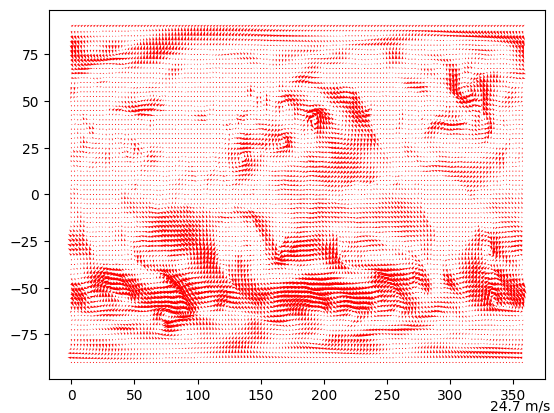

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import datetime
fname='May2000-uvt.nc'
ds = xr.open_dataset(fname, engine='scipy')
#select data for quiver
date1 = datetime.datetime(year=2000,day=10,month=5)
u=ds.u.sel(level=1000.0, time=date1, method="nearest")
v=ds.v.sel(level=1000.0, time=date1, method="nearest")
x=ds.longitude
y=ds.latitude
wmax=np.amax(np.sqrt(u**2+v**2)).values #find maximal windspeed in data
ax=plt.gca()
qv=ax.quiver(x,y, u, v, angles="xy", color="red")
q_typ=wmax
Qkey = ax.quiverkey(qv, 0.95,-0.12 , q_typ, '%.1f m/s' % q_typ, coordinates='axes')

How do we choose scale?

The maximum wind speed times the x size. The larger the scale, the smaller the arrow.

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (5,) and arg 1 with shape (5, 144).

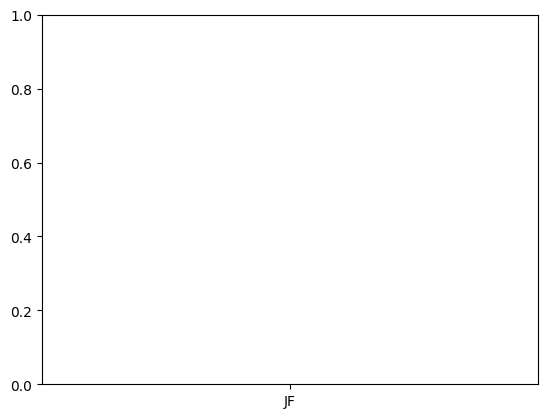

In [6]:
import datetime as dt
import matplotlib.pyplot as plt
tsurf=ds.t.sel(level=1000, latitude=53.55, method="nearest")
#define time bins corresponding to seasons
yy=2000
dd=15
time_bins=[dt.datetime(year=1999,month=1,day=dd),
dt.datetime(year=yy,month=2,day=dd),
dt.datetime(year=yy,month=5,day=dd),
dt.datetime(year=yy,month=8,day=dd),
dt.datetime(year=yy,month=11,day=dd),
dt.datetime(year=2001,month=12,day=dd)]
bin_labels=["JF", "MAM", "JJA", "SON", "D"]
#group temperature data by season bins and take average over all dimensions
tsm=tsurf.groupby_bins("time",time_bins, labels=bin_labels).mean()
# only the group "dimension" remain
plt.bar(tuple(bin_labels),tsm)
# we need to convert bin_labels to tuple since plt.bar() expects tuple argrument